# Recommendation Data and Popularity Baselines
**Task:** Clean and explore a movie-ratings dataset, measure its sparsity, and build a simple popularity-based recommender.

**Dataset:** `data/ratings.csv` (provided by the lecturer): `user_id`, `movie_id`, `movie_title`, `rating`, `timestamp`.

## 1. Load and inspect the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
df = pd.read_csv('data/ratings.csv')

**First 10 records**

In [2]:
df.head(10)

,user_id,movie_id,movie_title,rating,timestamp
0,U001,M001,Nairobi Nights,3,2026-01-01T08:00:00Z
1,U004,M001,Nairobi Nights,4,2026-01-06T09:00:00Z
2,U007,M001,Nairobi Nights,2,2026-01-11T10:00:00Z
3,U010,M001,Nairobi Nights,2,2026-01-16T11:00:00Z
4,U013,M001,Nairobi Nights,4,2026-01-21T12:00:00Z
5,U016,M001,Nairobi Nights,3,2026-01-26T13:00:00Z
6,U019,M001,Nairobi Nights,3,2026-01-31T14:00:00Z
7,U022,M001,Nairobi Nights,2,2026-02-05T15:00:00Z
8,U025,M001,Nairobi Nights,2,2026-02-10T16:00:00Z
9,U028,M001,Nairobi Nights,4,2026-02-15T17:00:00Z


**Dimensions and data types**

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
print(df.dtypes)

Rows: 305, Columns: 5

user_id          str
movie_id         str
movie_title      str
rating         int64
timestamp        str
dtype: object


**Missing values and duplicates**

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print(f"\nExact duplicate rows: {df.duplicated().sum()}")
print(f"Repeated (user_id, movie_id) pairs: {df.duplicated(['user_id', 'movie_id']).sum()}")

Missing values per column:
user_id        0
movie_id       0
movie_title    0
rating         0
timestamp      0
dtype: int64

Exact duplicate rows: 0
Repeated (user_id, movie_id) pairs: 3


The file has no missing values and no exact duplicate rows. However, a few users appear to have rated the same movie more than once (with different timestamps). Let's look at them.

In [5]:
repeats = df[df.duplicated(['user_id', 'movie_id'], keep=False)].sort_values(['user_id', 'movie_id', 'timestamp'])
repeats

,user_id,movie_id,movie_title,rating,timestamp
12,U008,M002,Savannah Run,2,2026-01-10T08:00:00Z
299,U008,M002,Savannah Run,2,2026-09-04T09:00:00Z
294,U034,M001,Nairobi Nights,4,2026-01-04T15:00:00Z
11,U034,M001,Nairobi Nights,3,2026-02-25T09:00:00Z
297,U041,M018,The Silent Drum,3,2026-04-28T10:00:00Z
211,U041,M018,The Silent Drum,4,2026-07-08T15:00:00Z


## 2. Clean the dataset

In [6]:
n_start = len(df)

# 2a. Remove exact duplicate records
df = df.drop_duplicates()

# 2b. Remove records with missing user or movie IDs
df = df.dropna(subset=['user_id', 'movie_id'])

# 2c. A user-item matrix needs ONE rating per user-movie pair.
#     Where a user rated the same movie twice, keep the most recent rating.
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = (df.sort_values('timestamp')
        .drop_duplicates(['user_id', 'movie_id'], keep='last')
        .sort_values(['user_id', 'movie_id'])
        .reset_index(drop=True))

print(f"Rows before cleaning: {n_start}")
print(f"Rows after cleaning:  {len(df)}  ({n_start - len(df)} removed)")

Rows before cleaning: 305
Rows after cleaning:  302  (3 removed)


**Confirm ratings fall within the expected scale (1 to 5)**

In [7]:
print("Rating range:", df['rating'].min(), "to", df['rating'].max())
print("Ratings outside 1-5:", (~df['rating'].between(1, 5)).sum())
print()
print(df['rating'].value_counts().sort_index())

Rating range: 1 to 5
Ratings outside 1-5: 0

rating
1      2
2     48
3    102
4    113
5     37
Name: count, dtype: int64


## 3. Explore the interaction data

In [8]:
n_ratings = len(df)
n_users = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()

user_counts = df['user_id'].value_counts()
movie_counts = df['movie_title'].value_counts()

print(f"Total number of ratings : {n_ratings}")
print(f"Unique users            : {n_users}")
print(f"Unique movies           : {n_movies}")
print(f"Most active user        : {user_counts.index[0]} ({user_counts.iloc[0]} ratings)")
print(f"Most-rated movie        : {movie_counts.index[0]} ({movie_counts.iloc[0]} ratings)")
print(f"Average rating (overall): {df['rating'].mean():.3f}")

Total number of ratings : 302
Unique users            : 50
Unique movies           : 24
Most active user        : U015 (8 ratings)
Most-rated movie        : Nairobi Nights (15 ratings)
Average rating (overall): 3.447


In [9]:
ties_u = user_counts[user_counts == user_counts.max()]
ties_m = movie_counts[movie_counts == movie_counts.max()]
print(f"Users tied for most active : {len(ties_u)} -> {list(ties_u.index)}")
print(f"Movies tied for most rated : {len(ties_m)} -> {list(ties_m.index)}")

Users tied for most active : 1 -> ['U015']
Movies tied for most rated : 1 -> ['Nairobi Nights']


`value_counts().index[0]` returns only one name when there is a tie, so the cell above checks for ties. Where several users or movies share the top count, all of them are equally "most active" or "most rated".

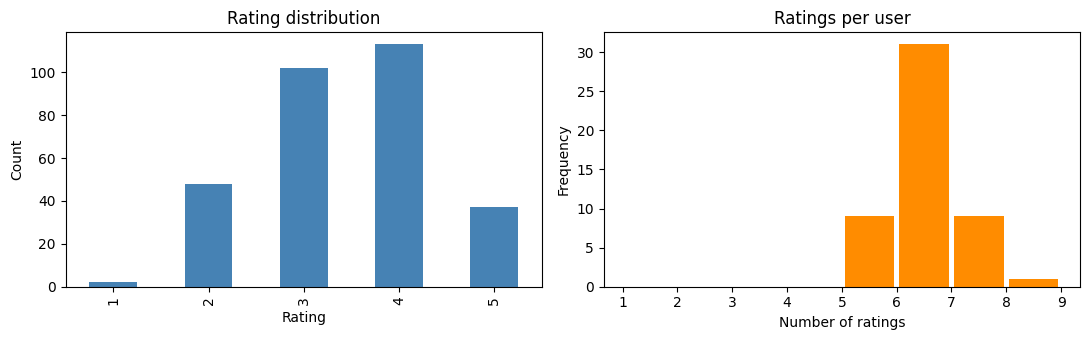

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df['rating'].value_counts().sort_index().plot.bar(ax=ax[0], color='steelblue')
ax[0].set_title('Rating distribution'); ax[0].set_xlabel('Rating'); ax[0].set_ylabel('Count')
user_counts.plot.hist(bins=range(1, user_counts.max() + 2), ax=ax[1], color='darkorange', rwidth=0.9)
ax[1].set_title('Ratings per user'); ax[1].set_xlabel('Number of ratings')
plt.tight_layout(); plt.show()

## 4. Create the user-item interaction matrix

In [11]:
matrix = df.pivot(index='user_id', columns='movie_id', values='rating')
print("Matrix shape (users x movies):", matrix.shape)
matrix.iloc[:10, :8]

Matrix shape (users x movies): (50, 24)


movie_id,M001,M002,M003,M004,M005,M006,M007,M008
user_id,,,,,,,,
U001,3.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN
U002,NaN,NaN,NaN,3.0,NaN,NaN,3.0,NaN
U003,NaN,NaN,NaN,NaN,4.0,NaN,NaN,4.0
U004,4.0,NaN,NaN,NaN,2.0,3.0,NaN,NaN
U005,NaN,NaN,NaN,3.0,NaN,NaN,5.0,NaN
U006,NaN,NaN,NaN,NaN,4.0,NaN,NaN,3.0
U007,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN
U008,NaN,2.0,NaN,NaN,NaN,NaN,5.0,NaN
U009,NaN,NaN,NaN,NaN,4.0,NaN,NaN,4.0


Rows are users, columns are movies, and each cell holds the rating (`NaN` = the user has not rated that movie).

## 5. Calculate sparsity

$$\text{Sparsity} = 1 - \frac{\text{number of ratings}}{\text{number of users} \times \text{number of movies}}$$

In [12]:
possible = n_users * n_movies
sparsity = 1 - n_ratings / possible
print(f"Observed ratings   : {n_ratings}")
print(f"Possible ratings   : {n_users} x {n_movies} = {possible}")
print(f"Density            : {n_ratings / possible:.2%}")
print(f"Sparsity           : {sparsity:.2%}")

Observed ratings   : 302
Possible ratings   : 50 x 24 = 1200
Density            : 25.17%
Sparsity           : 74.83%


**What it means:** the sparsity figure is the share of user-movie combinations with no rating. Most users have rated only a small fraction of the catalogue, so most of the matrix is empty. This is normal in recommender systems and is the core challenge: methods such as collaborative filtering must predict the missing cells from very little data.

## 6. Build a popularity-based recommender

In [13]:
movie_stats = (df.groupby(['movie_id', 'movie_title'])['rating']
                .agg(avg_rating='mean', num_ratings='count')
                .reset_index())
movie_stats['avg_rating'] = movie_stats['avg_rating'].round(3)
movie_stats.sort_values('avg_rating', ascending=False)

,movie_id,movie_title,avg_rating,num_ratings
12,M013,Midnight in Mombasa,4.417,12
20,M021,Market Day,4.333,12
13,M014,Code Breakers,4.167,12
19,M020,Home Again,4.083,12
6,M007,Hidden Lake,4.000,12
5,M006,City of Tomorrow,4.000,12
18,M019,Future Africa,3.917,12
3,M004,Coastal Dreams,3.833,12
11,M012,The Final Goal,3.833,12
9,M010,Beyond the Horizon,3.750,12


**Top 10 movies with at least 10 ratings** (ranked by average rating; ties broken by number of ratings)

In [14]:
MIN_RATINGS = 10
eligible = movie_stats[movie_stats['num_ratings'] >= MIN_RATINGS]
print(f"Movies meeting the {MIN_RATINGS}-rating threshold: {len(eligible)} of {len(movie_stats)}")

top10 = (eligible.sort_values(['avg_rating', 'num_ratings'], ascending=[False, False])
                 .head(10).reset_index(drop=True))
top10.index = top10.index + 1
top10.index.name = 'rank'
top10

Movies meeting the 10-rating threshold: 24 of 24


,movie_id,movie_title,avg_rating,num_ratings
rank,,,,
1,M013,Midnight in Mombasa,4.417,12
2,M021,Market Day,4.333,12
3,M014,Code Breakers,4.167,12
4,M020,Home Again,4.083,12
5,M006,City of Tomorrow,4.000,12
6,M007,Hidden Lake,4.000,12
7,M019,Future Africa,3.917,12
8,M004,Coastal Dreams,3.833,12
9,M012,The Final Goal,3.833,12


In [15]:
top10.reset_index().to_csv('top10_recommendations.csv', index=False)
print(pd.read_csv('top10_recommendations.csv'))

   rank movie_id          movie_title  avg_rating  num_ratings
0     1     M013  Midnight in Mombasa       4.417           12
1     2     M021           Market Day       4.333           12
2     3     M014        Code Breakers       4.167           12
3     4     M020           Home Again       4.083           12
4     5     M006     City of Tomorrow       4.000           12
5     6     M007          Hidden Lake       4.000           12
6     7     M019        Future Africa       3.917           12
7     8     M004       Coastal Dreams       3.833           12
8     9     M012       The Final Goal       3.833           12
9    10     M010   Beyond the Horizon       3.750           12


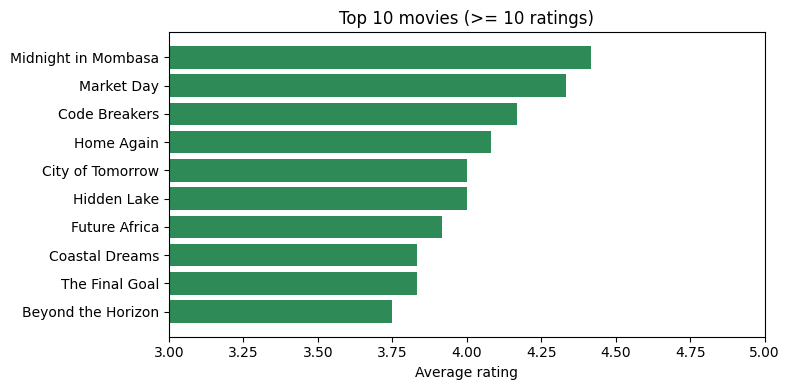

In [16]:
plt.figure(figsize=(8, 4))
plt.barh(top10['movie_title'][::-1], top10['avg_rating'][::-1], color='seagreen')
plt.xlim(3, 5); plt.xlabel('Average rating'); plt.title('Top 10 movies (>= 10 ratings)')
plt.tight_layout(); plt.show()

**Note on the threshold:** every movie in this dataset has at least 10 ratings, so the filter does not remove any movie here. It is still the right safeguard in general, because a movie with one 5-star rating would otherwise outrank a movie with hundreds of ratings averaging 4.6.

## 7. Interpret the results

In [17]:
cmp = movie_stats.sort_values('avg_rating', ascending=False)
print("Highest-rated :", cmp.iloc[0]['movie_title'], cmp.iloc[0]['avg_rating'])
print("Lowest-rated  :", cmp.iloc[-1]['movie_title'], cmp.iloc[-1]['avg_rating'])
print("Ratings per movie: min", movie_stats['num_ratings'].min(), "| max", movie_stats['num_ratings'].max())

Highest-rated : Midnight in Mombasa 4.417
Lowest-rated  : The Startup 2.583
Ratings per movie: min 12 | max 15


**Why the recommended movies are at the top.** The ranking uses average rating, so movies at the top are the ones whose raters scored them consistently high (mostly 4s and 5s). The minimum of 10 ratings means the averages rest on a reasonable number of votes rather than one or two enthusiastic users. Because all movies here have a similar number of ratings (12 to 15), the ranking is driven almost entirely by average score.

**One advantage.** It is simple, fast and needs no user history, so it works for brand-new users (the *cold-start user* problem) and gives a sensible default list to everyone.

**Two limitations.**
1. **No personalisation.** Every user gets the same list, regardless of taste. Someone who loves comedies still sees the top-rated thriller.
2. **Popularity bias and cold-start items.** The method favours movies that already have many good ratings, so new or niche movies never accumulate enough ratings to surface, and the list can become a self-reinforcing feedback loop. A high average from few ratings is also statistically noisy.